In [126]:
import pandas as pd

url = 'https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv'

df = pd.read_csv(url)

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


Precisão em porcentagem do desbalanceamento

In [127]:
df["Class"].value_counts(normalize=True)*100

,proportion
Class,
0,99.827251
1,0.172749


Feature Engineering

In [128]:
import numpy as np

df["Amount_log"] = np.log1p(df["Amount"])

In [129]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df["Amount_scaled"] = scaler.fit_transform(df[["Amount"]])
df = df.drop(columns=["Amount"])

In [130]:
from sklearn.model_selection import train_test_split

x = df.drop("Class", axis=1)
y = df["Class"]

x_train, x_test, y_train, y_test = train_test_split(x, y, stratify=y, test_size=0.3, random_state=42)

Logistic Regression - Regressão Logística

In [131]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=4500, random_state=42)

model.fit(x_train, y_train)

y_pred = model.predict(x_test)


In [132]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.84      0.62      0.72       148

    accuracy                           1.00     85443
   macro avg       0.92      0.81      0.86     85443
weighted avg       1.00      1.00      1.00     85443



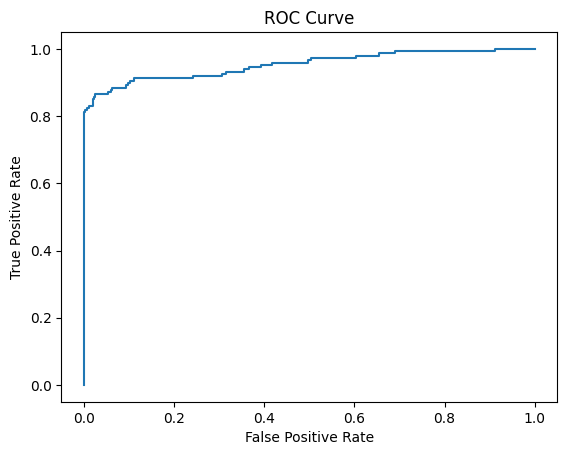

AUC:  95.27877018234014


In [133]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_probs = model.predict_proba(x_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_probs)

plt.plot(fpr, tpr)
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()


print("AUC: ", roc_auc_score(y_test, y_probs)*100)

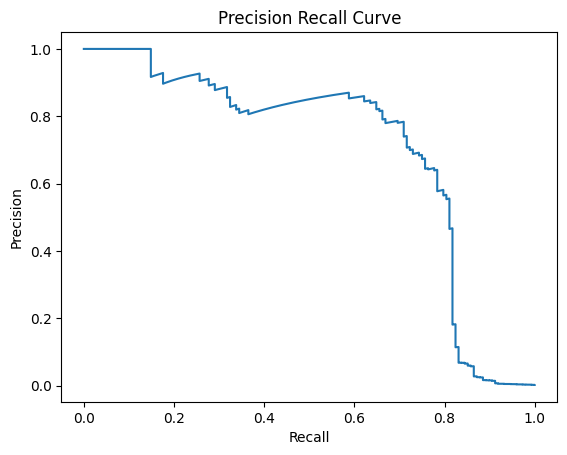

In [134]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_test, y_probs)

plt.plot(recall, precision)
plt.title("Precision Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()

Técnicas de Balanceamento

In [135]:
# Undersampling -> Subamostragem

fraudes = df[df["Class"] == 1]
normais = df[df["Class"] == 0].sample(len(fraudes), random_state=42)

df_under = pd.concat([fraudes, normais])

In [136]:
# Oversampling -> Sobreamostragem

from imblearn.over_sampling import SMOTE

smote = SMOTE()

x_res, y_res = smote.fit_resample(x, y)

Modelo Random Forest

In [137]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=50, max_depth=10, class_weight='balanced', n_jobs=-1, random_state=42)

rf.fit(x_train, y_train)

y_pred_rf = rf.predict(x_test)

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.83      0.76      0.80       148

    accuracy                           1.00     85443
   macro avg       0.92      0.88      0.90     85443
weighted avg       1.00      1.00      1.00     85443



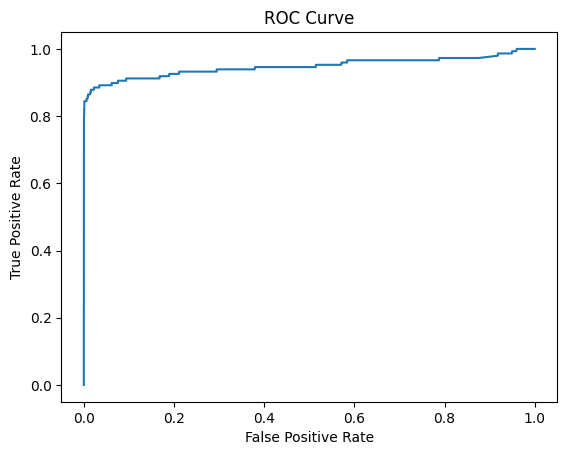

AUC:  94.74310144601486


In [138]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_probs = rf.predict_proba(x_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_probs)

plt.plot(fpr, tpr)
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()


print("AUC: ", roc_auc_score(y_test, y_probs)*100)

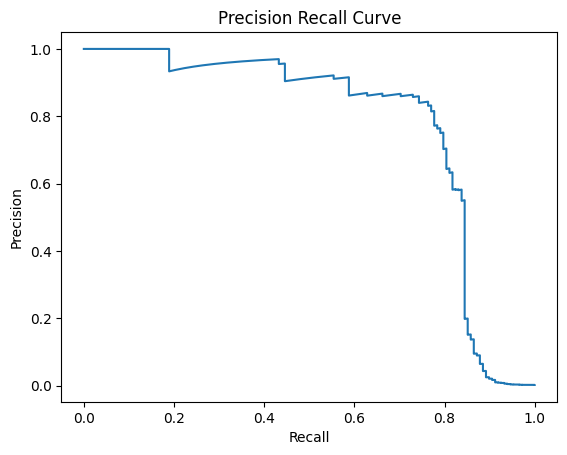

In [139]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_test, y_probs)

plt.plot(recall, precision)
plt.title("Precision Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()

Modelo Pipeline

In [140]:
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=4500))
])

pipeline.fit(x_train, y_train)

y_pred_pipeline = pipeline.predict(x_test)


In [141]:
print(classification_report(y_test, y_pred_pipeline))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.86      0.61      0.72       148

    accuracy                           1.00     85443
   macro avg       0.93      0.81      0.86     85443
weighted avg       1.00      1.00      1.00     85443



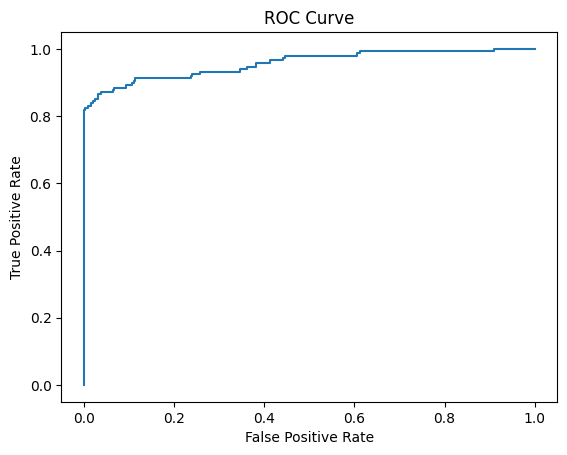

AUC:  95.68636988005065


In [142]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_probs = pipeline.predict_proba(x_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_probs)

plt.plot(fpr, tpr)
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()


print("AUC: ", roc_auc_score(y_test, y_probs)*100)

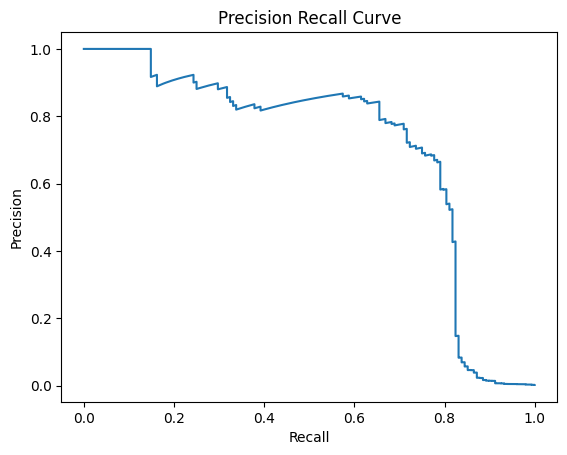

In [143]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_test, y_probs)

plt.plot(recall, precision)
plt.title("Precision Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()

Modelo XGboost

In [144]:
from xgboost import XGBClassifier

xgb = XGBClassifier(scale_pos_weight=10, use_label_encoder=False, eval_metric="logloss")

xgb.fit(x_train, y_train)

y_pred_xgb = xgb.predict(x_test)

/usr/local/lib/python3.13/dist-packages/xgboost/training.py:200: UserWarning: [19:49:46] WARNING: /__w/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [145]:
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.94      0.78      0.85       148

    accuracy                           1.00     85443
   macro avg       0.97      0.89      0.93     85443
weighted avg       1.00      1.00      1.00     85443



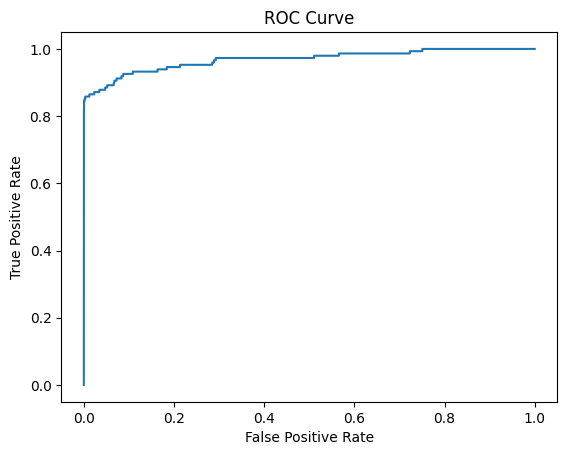

AUC:  96.8652474797325


In [146]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_probs = xgb.predict_proba(x_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_probs)

plt.plot(fpr, tpr)
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()


print("AUC: ", roc_auc_score(y_test, y_probs)*100)

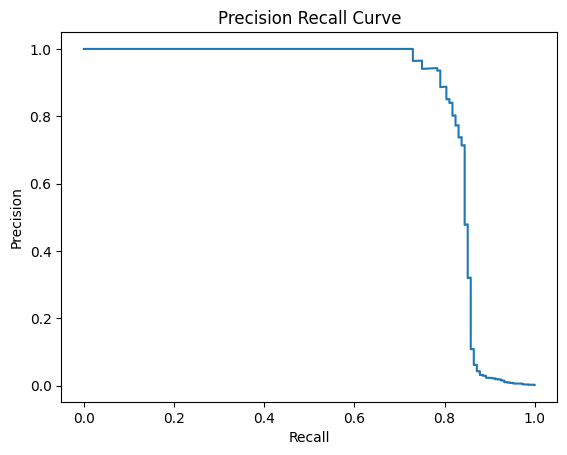

In [147]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_test, y_probs)

plt.plot(recall, precision)
plt.title("Precision Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()

Comparação dos modelos com os ajuste do limiar -> threshold 0.3

In [148]:
import pandas as pd
from sklearn.metrics import recall_score, precision_score, f1_score

def ajustes_threshold_modelos(nome, y_true, y_prob, threshold=0.3):
  y_pred = (y_prob > threshold).astype(int)

  return {
      "Modelo: ": nome,
      "Threshold: ": threshold,
      "Recall: (Fraude)": recall_score(y_true, y_pred, pos_label=1)*100,
      "Precision: (Fraude)": precision_score(y_true, y_pred, pos_label=1)*100,
      "f1 score: (Fraude)": f1_score(y_true, y_pred, pos_label=1)*100
  }


y_probs_lr = model.predict_proba(x_test)[:, 1]
y_probs_rf = rf.predict_proba(x_test)[:, 1]
y_probs_xgb = xgb.predict_proba(x_test)[:, 1]
y_probs_pipeline = pipeline.predict_proba(x_test)[:, 1]


resultados_finais = [
  ajustes_threshold_modelos("Regressão Logística", y_test, y_probs_lr),
  ajustes_threshold_modelos("Random Forest", y_test, y_probs_rf),
  ajustes_threshold_modelos("Pipeline", y_test, y_probs_pipeline),
  ajustes_threshold_modelos("XGBoost", y_test, y_probs_xgb)
]

df_comparacao_final = pd.DataFrame(resultados_finais)
df_comparacao_final = df_comparacao_final.sort_values(by="Recall: (Fraude)", ascending=False).reset_index(drop=True)
display(df_comparacao_final)


,Modelo:,Threshold:,Recall: (Fraude),Precision: (Fraude),f1 score: (Fraude)
0,Random Forest,0.3,81.081081,63.157895,71.005917
1,XGBoost,0.3,79.054054,90.697674,84.476534
2,Regressão Logística,0.3,66.891892,78.571429,72.262774
3,Pipeline,0.3,65.540541,79.508197,71.851852


Melhor modelo avaliado de acordo com as métricas foi o XGBoost devido ao equilibrio entre elas: Alta precisão: 90%; Recall de 79% e f1 score de 84%

=== MATRIZ DE CONFUSÃO (XGBoost - Threshold 0.3) ===
[[85283    12]
 [   31   117]]

=== RELATÓRIO DE CLASSIFICAÇÃO DETALHADO ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.91      0.79      0.84       148

    accuracy                           1.00     85443
   macro avg       0.95      0.90      0.92     85443
weighted avg       1.00      1.00      1.00     85443



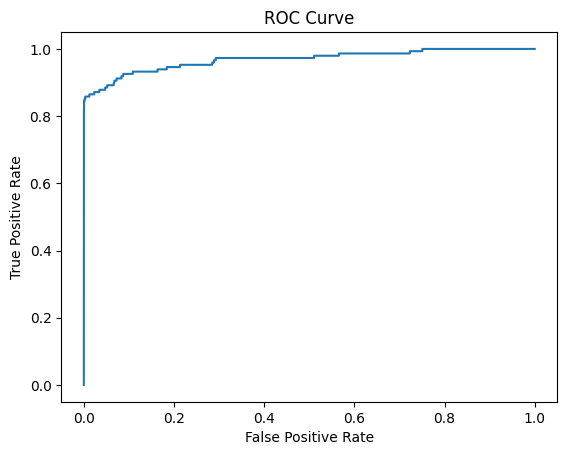

AUC:  96.8652474797325


In [149]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score
threshold = 0.3
y_pred_xgb_custom = (y_probs_xgb > threshold).astype(int)

print("=== MATRIZ DE CONFUSÃO (XGBoost - Threshold 0.3) ===")
print(confusion_matrix(y_test, y_pred_xgb_custom))

print("\n=== RELATÓRIO DE CLASSIFICAÇÃO DETALHADO ===")
print(classification_report(y_test, y_pred_xgb_custom))

fpr, tpr, _ = roc_curve(y_test, y_probs_xgb)

plt.plot(fpr, tpr)
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()


print("AUC: ", roc_auc_score(y_test, y_probs_xgb)*100)


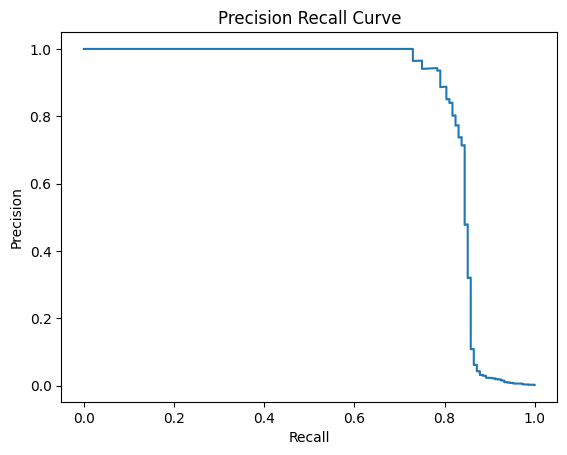

In [150]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_test, y_probs_xgb)

plt.plot(recall, precision)
plt.title("Precision Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()

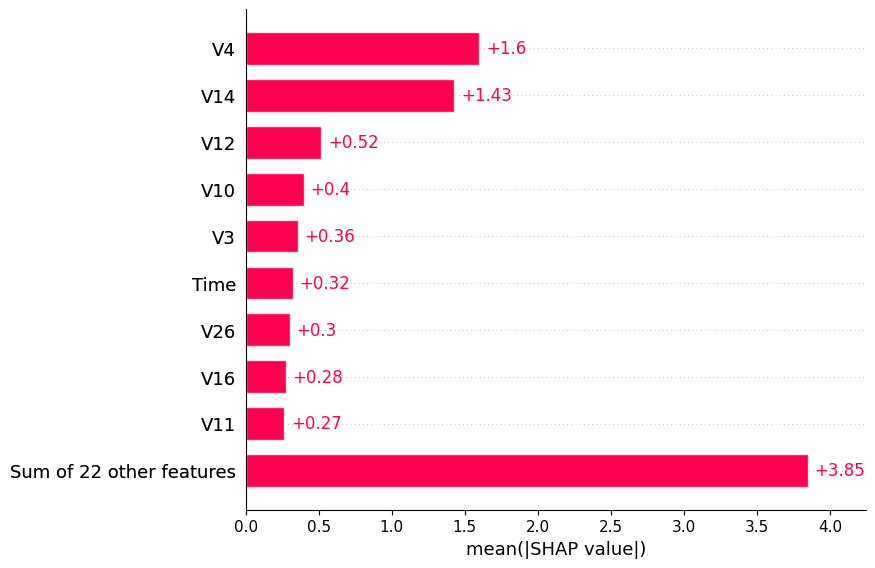

In [151]:
import shap

explainer = shap.Explainer(xgb)
shap_values = explainer(x_test.iloc[:100])

shap.plots.bar(shap_values)